# CNN Multi Dim Analysis

### Imports, datasets and types

In [ ]:
%load_ext autoreload
%autoreload 2

import gc
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import umap
from open_mm_v2 import simulate_murd_short_md
from plots import (
    all_base_plots,
    plot_dope_interp_scores,
    plot_dope_mesh,
    plot_pairwise_rmsd,
)
from sklearn.decomposition import PCA
from torch import Tensor
from utils import (
    TrainConfig,
    composite_loss,
    get_all_stats,
    make_hyperlatent_mlp_mas,
)

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *
from molearn.analysis.plot import plot_rmsd_hist
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder, LatentAutoencoder, ToND

device: str = "cuda" if torch.cuda.is_available() else "cpu"
atoms: list[str] = ["N", "CA", "C", "O", "CB"]

with open("../data/data_statistics_full.json") as f:
    stats = json.load(f)

mean: float = stats["mean"]
std: float = stats["std"]

data_closed = PDBData(
    filename=["../data/full_murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_closed.prepare_dataset(mean=mean, std=std)


data_open = PDBData(
    filename=["../data/full_murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_open.prepare_dataset(mean=mean, std=std)

data_both = PDBData(
    filename=["../data/full_murd_both.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_both.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full_murd_test.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_test.prepare_dataset(mean=mean, std=std)

data_5a5e = PDBData(
    filename=["../data/5A5E.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_5a5e.prepare_dataset(mean=mean, std=std)

data_5a5f = PDBData(
    filename=["../data/5A5F.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_5a5f.prepare_dataset(mean=mean, std=std)

Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([4000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1600, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1, 2145, 3])


### Loading results

In [2]:
BASE_PATH: str = r"../results/11-feb-2026-latent-dim-physics"
RUNS: list[int] = list(range(1, 16))
ALL_VARS: list[int] = list(range(2, 21))
N_ATOMS: int = 2145
RANDOM_STATE: int = 42
CLOSED_COLOR: str = "#AFC2DC"
OPEN_COLOR: str = "#FDBFCA"
BOTH_COLOR: str = "#FDBFCA"
TEST_COLOR: str = "#7FB069"

KEYS_ALL = ("train_open", "train_closed", "train_both", "test_trans")
KEYS_BOTH = ("train_both", "test_trans")
KEYS_NO_BOTH = ("train_open", "train_closed", "test_trans")

PlotData = list[tuple[str, ...]]


log_dfs: dict[int, dict[int, pd.DataFrame]]
min_valid_losses: dict[int, dict[int, float]]
min_valid_mse_losses: dict[int, dict[int, float]]
models: dict[int, dict[int, AutoEncoder]]
MAs: dict[int, dict[int, MolearnAnalysis]]

log_dfs, min_valid_losses, min_valid_mse_losses, models, MAs = (
    {t: {} for t in RUNS} for _ in range(5)
)


for t in RUNS:
    for var in ALL_VARS:
        log_dfs[t][var] = pd.read_csv(Path(f"{BASE_PATH}/{t}/{var}/log.dat"))
        best_epoch: int = log_dfs[t][var]["valid_loss"].idxmin()  # type: ignore[assignment]
        min_valid_losses[t][var] = min(log_dfs[t][var].valid_loss)
        min_valid_mse_losses[t][var] = min(log_dfs[t][var].valid_mse_loss)

        checkpoint_path: Path = Path(f"{BASE_PATH}/{t}/{var}/checkpoint_converged.ckpt")
        checkpoint: dict = torch.load(
            checkpoint_path, map_location=device, weights_only=False
        )

        model: AutoEncoder = AutoEncoder(n_atoms=N_ATOMS, latent_dim=var)
        model.load_state_dict(checkpoint["model_state_dict"])

        models[t][var] = model

        MA: MolearnAnalysis = MolearnAnalysis()
        MA.batch_size = 16
        MA.processes = 4

        MA.set_dataset(data=data_open, key="train_open")
        MA.set_dataset(data=data_closed, key="train_closed")
        MA.set_dataset(data=data_both, key="train_both")
        MA.set_dataset(data=data_test, key="test_trans")
        MA.set_dataset(data=data_5a5e, key="5A5E")
        MA.set_dataset(data=data_5a5f, key="5A5F")

        MA.set_network(models[t][var])

        MAs[t][var] = MA

## Base plots

### All stats calculation (and test)

In [ ]:
KEYS = ["train_both"]

plot_data: PlotData = [
    ("train_both", "Train Both", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

for run in [[15]]:
    save_dir = Path(f"../statistics/all_stats_both_r{run[0]}")
    df = get_all_stats(
        mas=MAs,
        varis=ALL_VARS,
        runs=run,
        keys=KEYS,
        random_state=RANDOM_STATE,
        save_dir=save_dir,
    )

encoding train_both: 250it [00:01, 204.39it/s]
Decoding train_both: 250it [00:02, 107.20it/s]
encoding train_both: 250it [00:00, 251.46it/s]
Decoding train_both: 250it [00:01, 154.45it/s]
encoding train_both: 250it [00:00, 298.33it/s]
Decoding train_both: 250it [00:00, 345.33it/s]
encoding train_both: 250it [00:00, 276.75it/s]
Decoding train_both: 250it [00:01, 146.64it/s]
encoding train_both: 250it [00:00, 277.71it/s]
Decoding train_both: 250it [00:01, 163.56it/s]
encoding train_both: 250it [00:00, 277.66it/s]
Decoding train_both: 250it [00:01, 172.44it/s]
encoding train_both: 250it [00:00, 250.37it/s]
Decoding train_both: 250it [00:01, 144.06it/s]
encoding train_both: 250it [00:00, 289.97it/s]
Decoding train_both: 250it [00:00, 343.27it/s] 
encoding train_both: 250it [00:01, 245.50it/s]
Decoding train_both: 250it [00:01, 135.00it/s]
encoding train_both: 250it [00:00, 256.62it/s]
Decoding train_both: 250it [00:01, 147.36it/s]
encoding train_both: 250it [00:00, 288.69it/s]
Decoding tra

### Model architecture and shapes

In [13]:
def print_encoder_shapes(model: AutoEncoder, n_atoms: int) -> None:
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x: Tensor = torch.randn(1, n_atoms, 3)

    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")

    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed: Tensor = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)

        # Print shape after certain layer types
        print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal latent shape: {x.shape}")


# Test with your model

var: int = 2
run: int = 1

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
print_encoder_shapes(models[run][var], n_atoms=N_ATOMS)

ENCODER FORWARD PASS - latent_dim=2
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 1 (BatchNorm1d): torch.Size([1, 32, 1072])
Layer 2 (ReLU): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 4 (BatchNorm1d): torch.Size([1, 48, 536])
Layer 5 (ReLU): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 7 (BatchNorm1d): torch.Size([1, 72, 268])
Layer 8 (ReLU): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 10 (BatchNorm1d): torch.Size([1, 108, 134])
Layer 11 (ReLU): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 13 (BatchNorm1d): torch.Size([1, 162, 67])
Layer 14 (ReLU): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 2])

Final latent shape: torch.Size([1, 2])


In [11]:
def print_decoder_shapes(model: AutoEncoder, latent_dim: int) -> Tensor:
    """Print the shape at each stage of the decoder"""
    # Create dummy latent input: (batch=1, latent_dim)
    x: Tensor = torch.randn(1, latent_dim)
    print(f"Input latent shape: {x.shape}")

    for i, m in enumerate(model.decoder):
        x = m(x)

        # Print shape after certain layer types
        # if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
        print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal output shape: {x.shape}")
    return x


# Test with your model
var: int = 2
run: int = 1

print("=" * 60)
print(f"DECODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
decoded: Tensor = print_decoder_shapes(models[run][var], var)
print(f"\nExpected atoms: {data_open.dataset.shape[1]}")
print(f"Decoder output atoms: {decoded.shape[2]}")
print(f"Difference: {decoded.shape[2] - data_open.dataset.shape[1]} atoms discarded")

DECODER FORWARD PASS - latent_dim=2
Input latent shape: torch.Size([1, 2])
Layer 0 (FromND): torch.Size([1, 1, 17])
Layer 1 (ConvTranspose1d): torch.Size([1, 243, 34])
Layer 2 (BatchNorm1d): torch.Size([1, 243, 34])
Layer 3 (ReLU): torch.Size([1, 243, 34])
Layer 4 (ConvTranspose1d): torch.Size([1, 162, 68])
Layer 5 (BatchNorm1d): torch.Size([1, 162, 68])
Layer 6 (ReLU): torch.Size([1, 162, 68])
Layer 7 (ConvTranspose1d): torch.Size([1, 108, 136])
Layer 8 (BatchNorm1d): torch.Size([1, 108, 136])
Layer 9 (ReLU): torch.Size([1, 108, 136])
Layer 10 (ConvTranspose1d): torch.Size([1, 72, 272])
Layer 11 (BatchNorm1d): torch.Size([1, 72, 272])
Layer 12 (ReLU): torch.Size([1, 72, 272])
Layer 13 (ConvTranspose1d): torch.Size([1, 48, 544])
Layer 14 (BatchNorm1d): torch.Size([1, 48, 544])
Layer 15 (ReLU): torch.Size([1, 48, 544])
Layer 16 (ConvTranspose1d): torch.Size([1, 32, 1088])
Layer 17 (BatchNorm1d): torch.Size([1, 32, 1088])
Layer 18 (ReLU): torch.Size([1, 32, 1088])
Layer 19 (ConvTranspose

### MSE Plots 

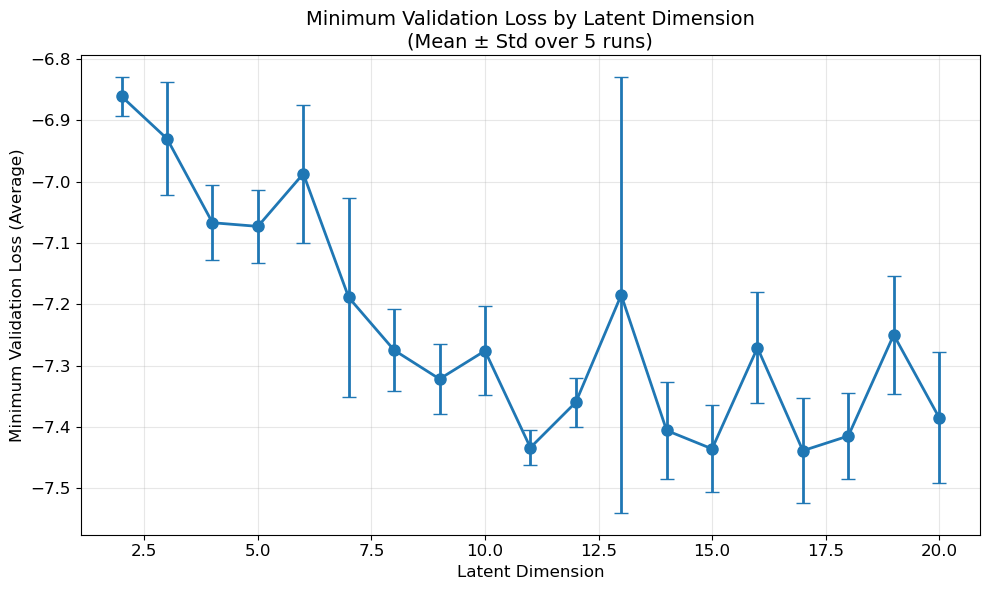

In [18]:
# Plot line graph of minimum validation losses (averaged over triplicates)

avg_valid_losses: dict[int, float] = {}
std_valid_losses: dict[int, float] = {}

for var in ALL_VARS:
    losses: list[float] = [min_valid_losses[t][var] for t in RUNS]
    avg_valid_losses[var] = float(np.mean(losses))
    std_valid_losses[var] = float(np.std(losses))

plt.figure(figsize=(10, 6))
plt.errorbar(
    list(avg_valid_losses.keys()),
    list(avg_valid_losses.values()),
    yerr=list(std_valid_losses.values()),
    marker="o",
    linewidth=2,
    markersize=8,
    capsize=5,
)
plt.xlabel("Latent Dimension", fontsize=12)
plt.ylabel("Minimum Validation Loss (Average)", fontsize=12)
plt.title(
    "Minimum Validation Loss by Latent Dimension\n(Mean ± Std over 5 runs)",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model plots

#### Setup

In [11]:
median_models: list[list[int]] = []

for var in ALL_VARS:
    losses = [(min_valid_losses[t][var], t) for t in RUNS]
    losses.sort()
    median_run = losses[len(losses) // 2][1]
    median_models.append([median_run, var])

print(median_models)

plot_data: PlotData = [
    ("train_both", "Train Both", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

[[8, 2], [1, 3], [12, 4], [13, 5], [12, 6], [5, 7], [14, 8], [5, 9], [10, 10], [11, 11], [14, 12], [11, 13], [5, 14], [11, 15], [11, 16], [2, 17], [15, 18], [15, 19], [3, 20]]


#### RMSD Hist plot

Decoding train_both: 250it [00:01, 141.11it/s]
Decoding test_trans: 100it [00:00, 177.23it/s]


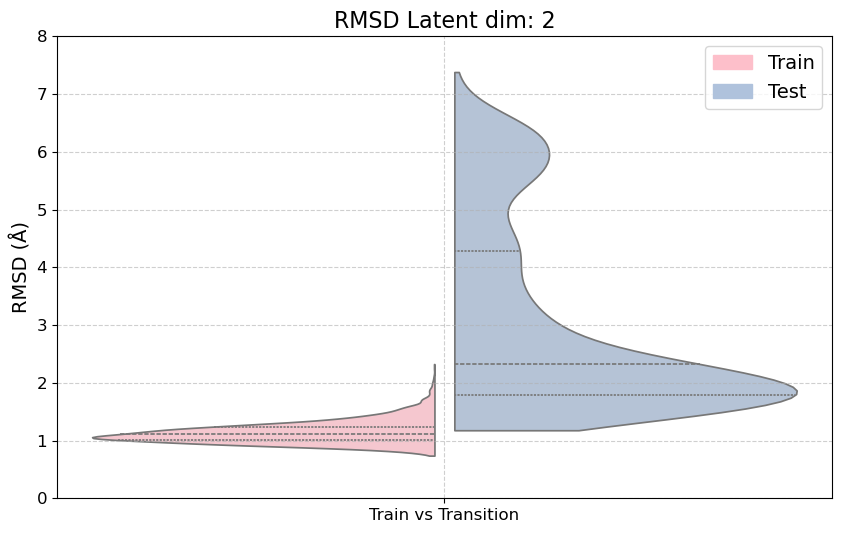

encoding train_both: 250it [00:00, 290.56it/s]
Decoding train_both: 250it [00:01, 170.00it/s]
encoding test_trans: 100it [00:00, 260.96it/s]
Decoding test_trans: 100it [00:00, 153.66it/s]


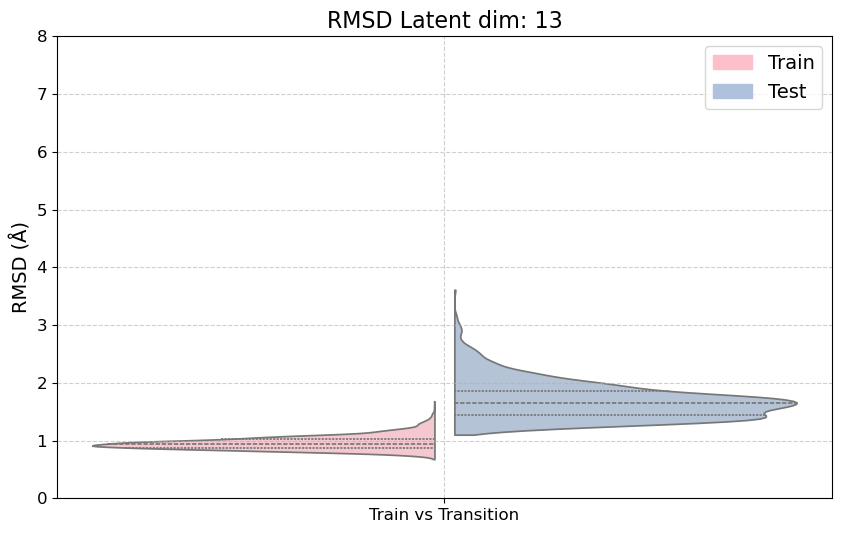

In [ ]:
for run, var in [[12, 2], [10, 13]]:
    rmsd_plot_data: PlotData = [
        ("train_both", "test_trans", "Train vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[run][var],
        plot_data=rmsd_plot_data,
        dpi=150,
        var=var,
    )

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=2


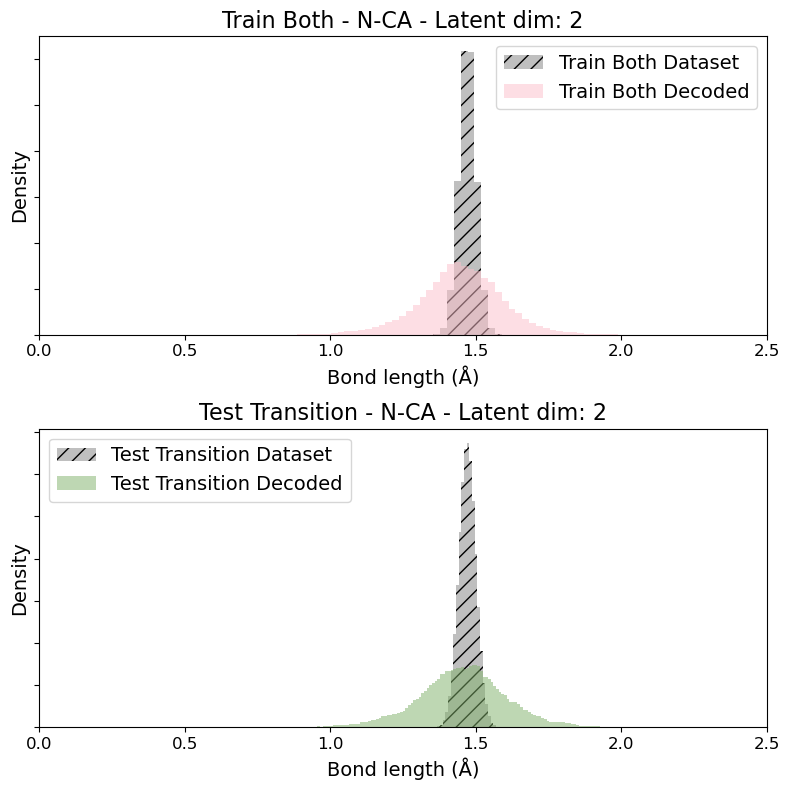

BOND LENGTH DISTRIBUTIONS - latent_dim=13


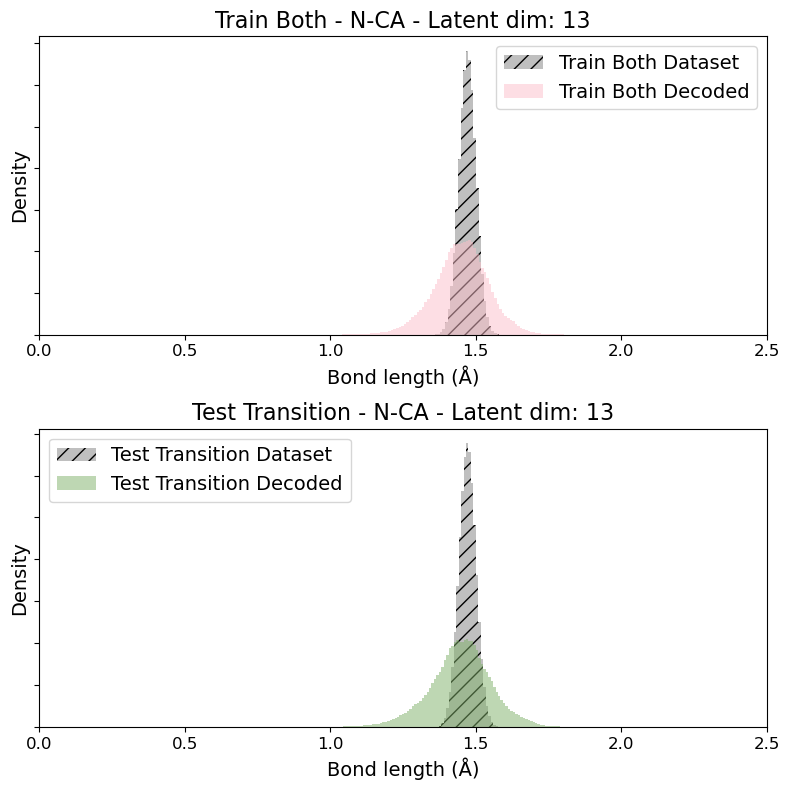

In [ ]:
for run, var in [[12, 2], [10, 13]]:
    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={var}")
    print("=" * 60)

    plot_bondlength_hist(
        MAs[run][var],
        plot_data=plot_data,
        bins=300,
        dpi=150,
        bond_types=["N-CA"],
        latent_dim=var,
    )

#### Inversion Hist Plot

INVERSION ERRORS - latent_dim=2, run=12


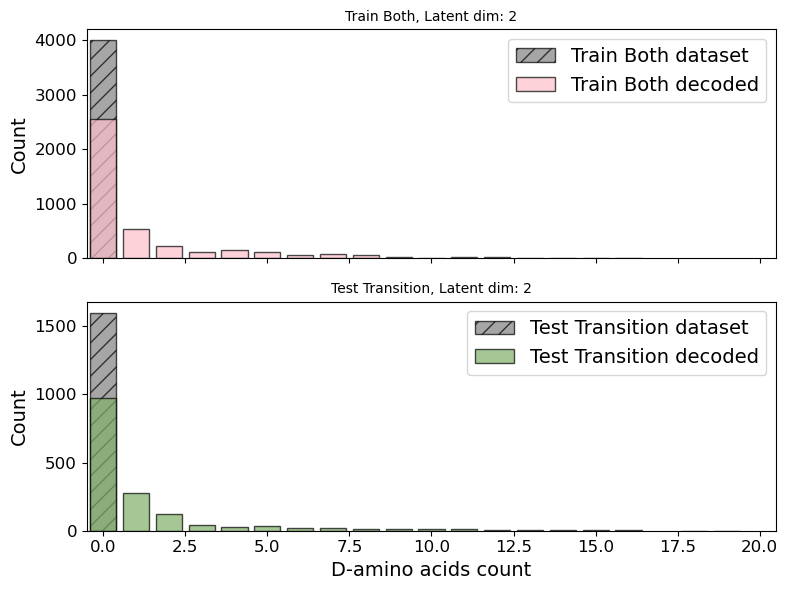

INVERSION ERRORS - latent_dim=13, run=10


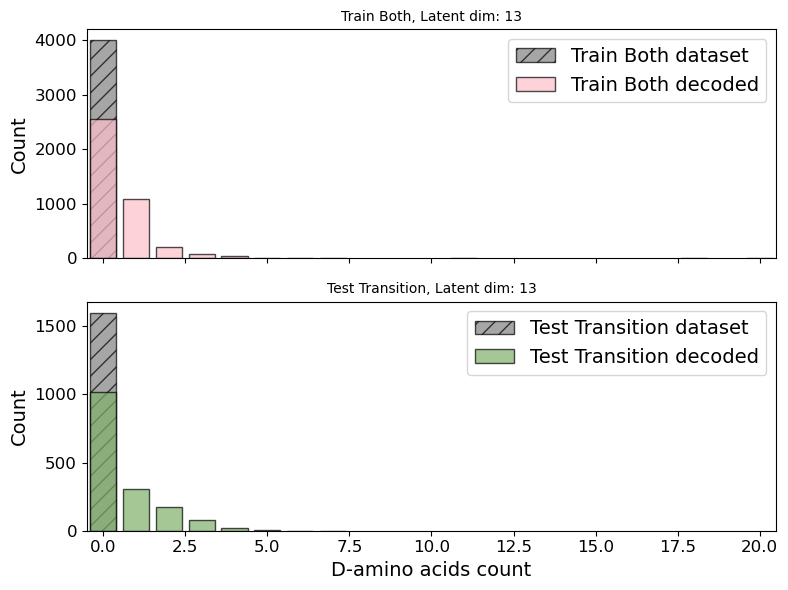

In [13]:
for run, var in [[12, 2], [10, 13]]:
    print("=" * 60)
    print(f"INVERSION ERRORS - latent_dim={var}, run={run}")
    print("=" * 60)

    plot_inversion_hist(
        MAs[run][var], plot_data=plot_data, latent_dim=var, show_plot=True
    )

#### Wiszniowski plot

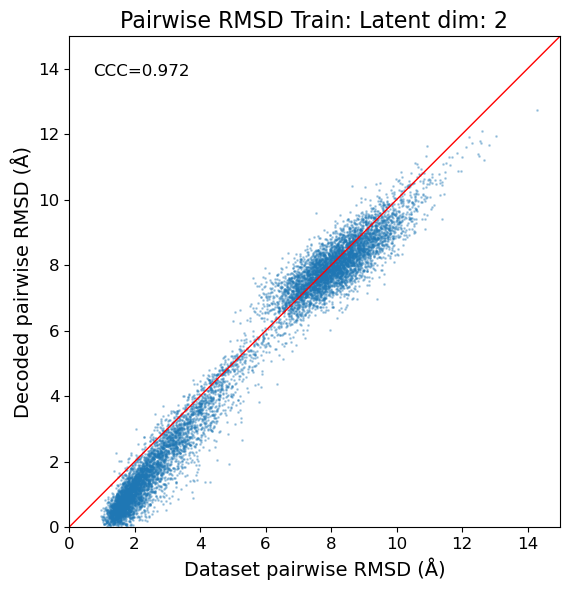

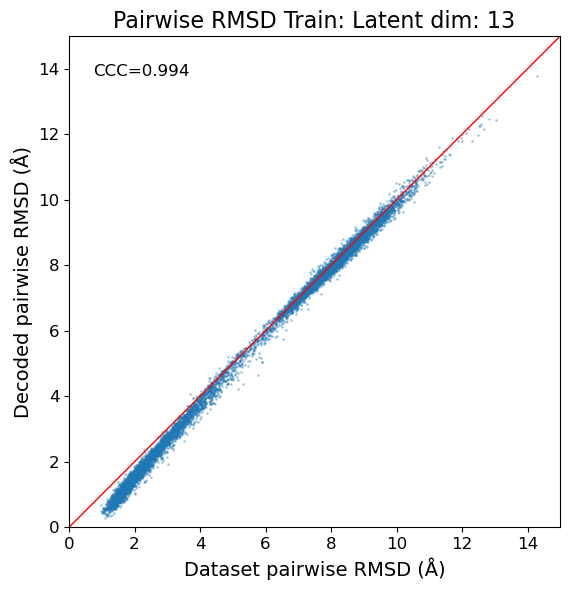

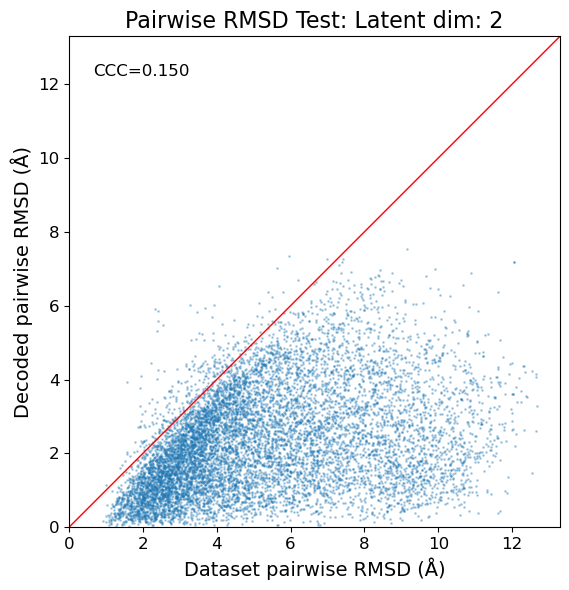

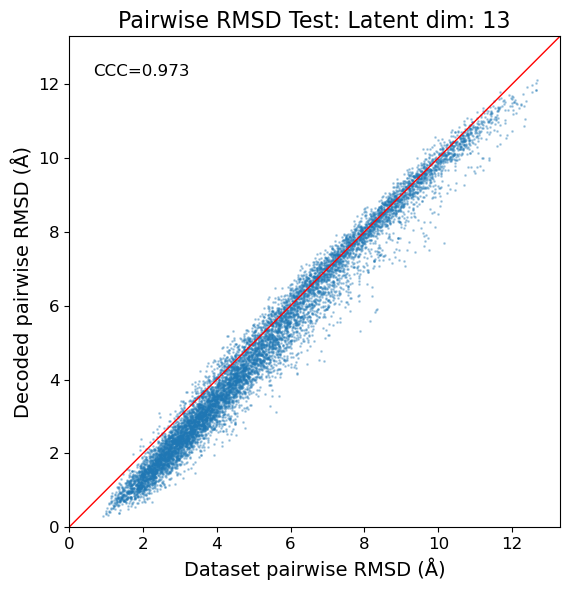

In [ ]:
for key in KEYS_BOTH:
    for run, var in [[12, 2], [10, 13]]:
        ccc, _, _ = plot_pairwise_rmsd(
            MAs[run][var],
            key=key,
            latent_dim=var,
            show_plot=True,
            title=f"Pairwise RMSD — Latent Dim {var}",
            max_pairs=10000,
        )

## 2D Hyperlatent representations


### Setup

In [ ]:
N_SAMPLES: int = 70
REFINE: bool = True
TRUNCATE_AT: int = -23000

run = 3
var = 14

ma = MAs[run][var]

encoded_test: np.ndarray = MAs[run][var].get_encoded("test_trans").numpy()
encoded_open: np.ndarray = MAs[run][var].get_encoded("train_open").numpy()
encoded_closed: np.ndarray = MAs[run][var].get_encoded("train_closed").numpy()
encoded_all = np.vstack([encoded_test, encoded_open, encoded_closed])

centroid_open = encoded_open.mean(axis=0)
centroid_closed = encoded_closed.mean(axis=0)

encoded_datasets = [
    (encoded_test, "Test Transition", TEST_COLOR),
    (encoded_open, "Train Open", OPEN_COLOR),
    (encoded_closed, "Train Closed", CLOSED_COLOR),
]

plot_data: PlotData = [
    ("train_both", "Train Closed", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

encoding test_trans: 100it [00:00, 140.88it/s]
encoding train_open: 125it [00:00, 140.40it/s]
encoding train_closed: 125it [00:00, 150.06it/s]


### PCA

#### 2D Dope

In [4]:
grid_key: str = ma.setup_grid(samples=N_SAMPLES)  # changes require kernel restart
dope_surface, xvals, yvals = ma.scan_dope(refine=REFINE)

dope_plot_data: list[tuple[str, ...]] = [
    ("train_open", "Train Open", OPEN_COLOR, "scatter"),
    ("train_closed", "Train Closed", CLOSED_COLOR, "scatter"),
    ("test_trans", "Test Transition", TEST_COLOR, "scatter"),
]

plot_dope_surface(
    ma=ma,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    plot_data=dope_plot_data,
    cmap="viridis",
    bbox_inches="tight",
)

encoding train_both: 250it [00:01, 142.79it/s]
encoding 5A5E: 1it [00:00, 106.48it/s]
encoding 5A5F: 1it [00:00, 165.27it/s]
Decoding grid: 0it [00:00, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x2 and 14x17)

#### plot

var1: 75.60950469970703
var2: 17.088966369628906
var total: 92.69847106933594
run: 2, var: 5
Decoding 10x10 = 100 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 100/100 [00:06<00:00, 15.63it/s]


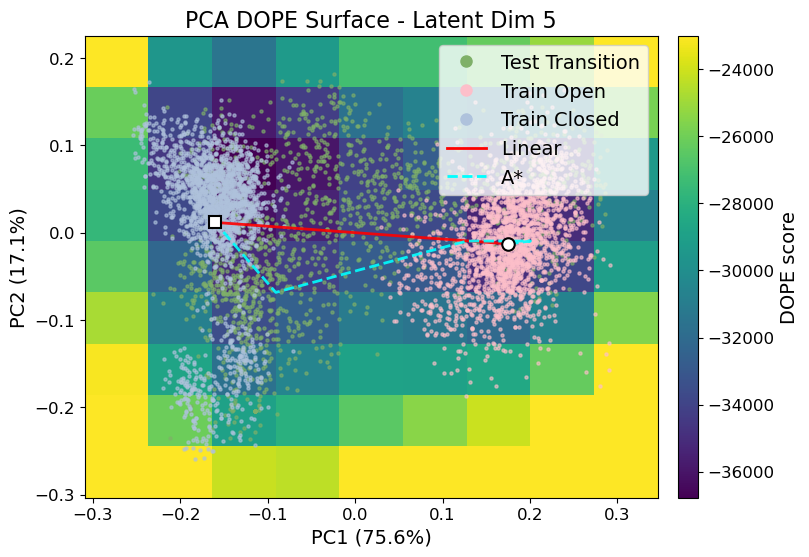

In [ ]:
pca = PCA(n_components=2)
pca.fit(encoded_all)

var_pc1: float = pca.explained_variance_ratio_[0] * 100
var_pc2: float = pca.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2

print(f"var1: {var_pc1}")
print(f"var2: {var_pc2}")
print(f"var total: {var_total}")
print(f"run: {run}, var: {var}")


# --- 1. Generate the DOPE mesh and keep the surface + axes ---------------
dope_surface, d1_vals, d2_vals, fig, ax, paths = plot_dope_mesh(
    ma=ma,
    encoded_datasets=encoded_datasets,
    mapping=pca.transform,
    inverse_mapping=pca.inverse_transform,
    n_samples=10,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"PCA DOPE Surface - Latent Dim {var}",
    xlabel=f"PC1 ({var_pc1:.1f}%)",
    ylabel=f"PC2 ({var_pc2:.1f}%)",
    plot_crystals=False,
    plot_linear=True,
    plot_astar=True,
    start_encoded=centroid_open,
    end_encoded=centroid_closed,
    show=True,
)

#### Saving interpolation stats

In [ ]:
for name, latent_coords in paths.items():
    MAs[run][var].set_encoded(name, latent_coords)


keys = ["astar", "linear"]
save_dir = "figures/interpolation_test/"

plot_data_interp: PlotData = [
    ("astar", "A Star", "cyan"),
    ("linear", "Linear", "red"),
]

all_base_plots(
    ma=ma,
    keys=keys,
    plot_data=plot_data_interp,
    latent_dim=var,
    run=run,
    save_dir=save_dir,
)

#### Saving stats

encoding train_open: 0it [00:00, ?it/s]

encoding train_open: 125it [00:00, 187.03it/s]
encoding train_closed: 125it [00:00, 218.29it/s]
encoding train_both: 250it [00:01, 211.10it/s]
encoding test_trans: 100it [00:00, 221.83it/s]
Decoding train_both: 250it [00:01, 129.05it/s]
Decoding test_trans: 100it [00:00, 105.56it/s]


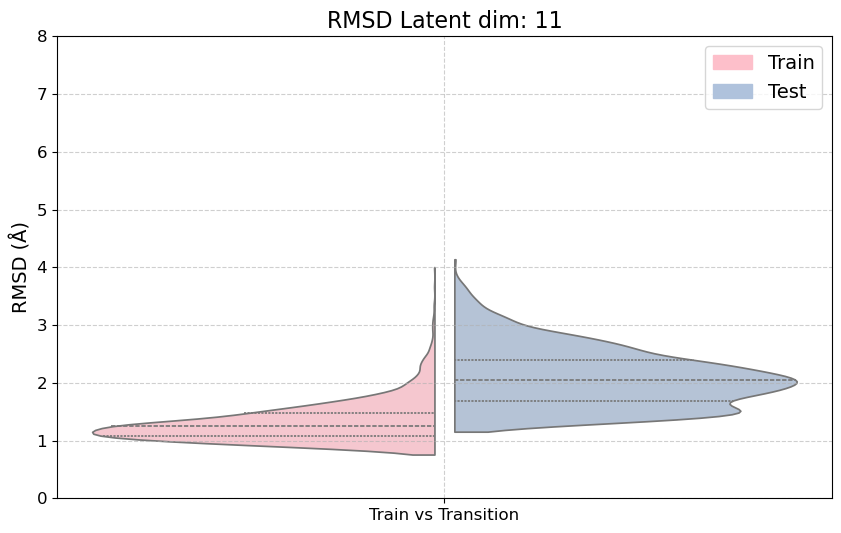

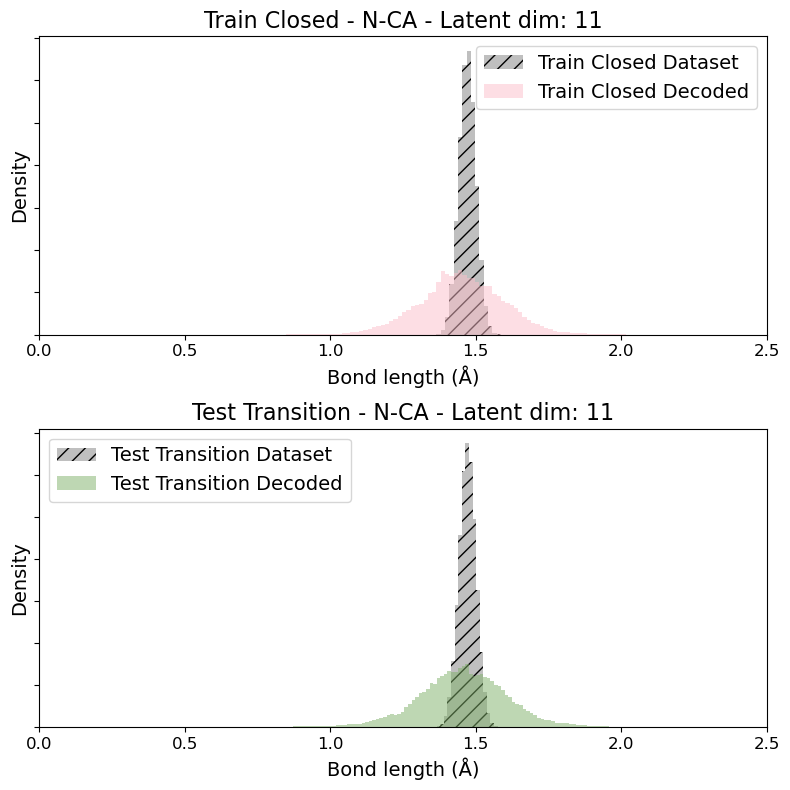

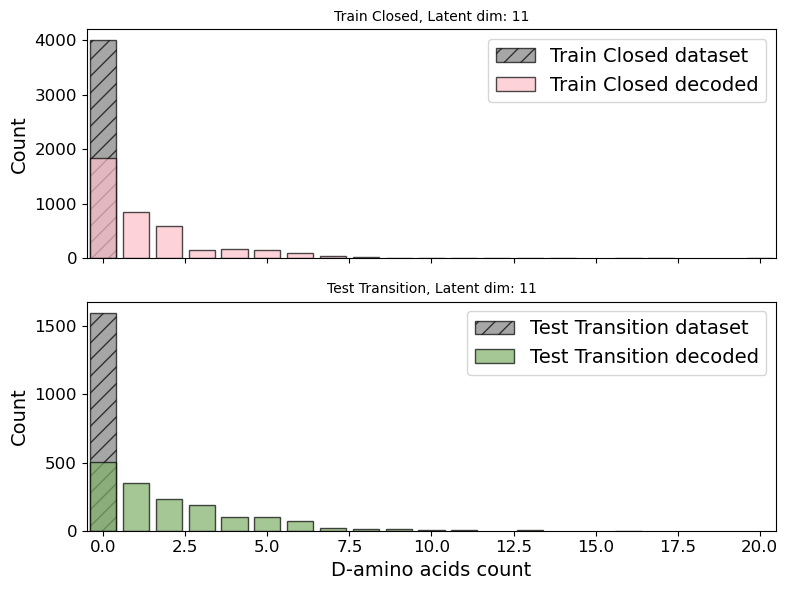

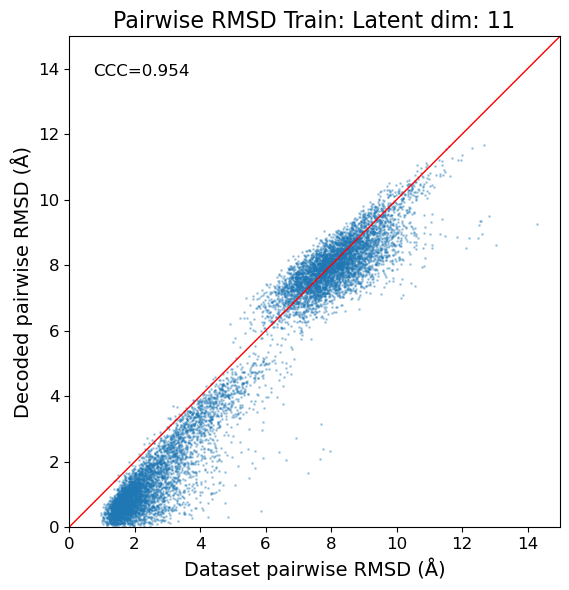

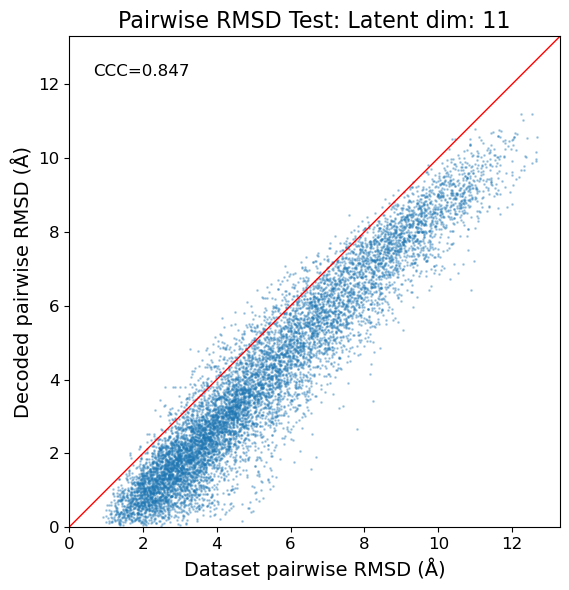

In [ ]:
pca_mas: dict[int, dict[int, MolearnAnalysis]] = {}


pca_mas, mappings, inverse_mappings = make_hyperlatent_pca_mas(
    mas=MAs,
    runs=[run],
    varis=[var],
    keys=KEYS_ALL,
)

get_all_stats(
    mas=pca_mas,
    runs=[run],
    varis=[var],
    keys=KEYS_NO_BOTH,
    save_dir=Path("../statistics/pca_r10_v13_stats"),
    random_state=RANDOM_STATE,
)

ma = pca_mas[run][var]

all_base_plots(
    ma=ma,
    keys=KEYS_BOTH,
    plot_data=plot_data,
    latent_dim=var,
    run=run,
    save_dir="../figures/best/test/",
)

### UMAP

Decoding 15x15 = 225 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 17/17 [00:01<00:00, 16.12it/s]


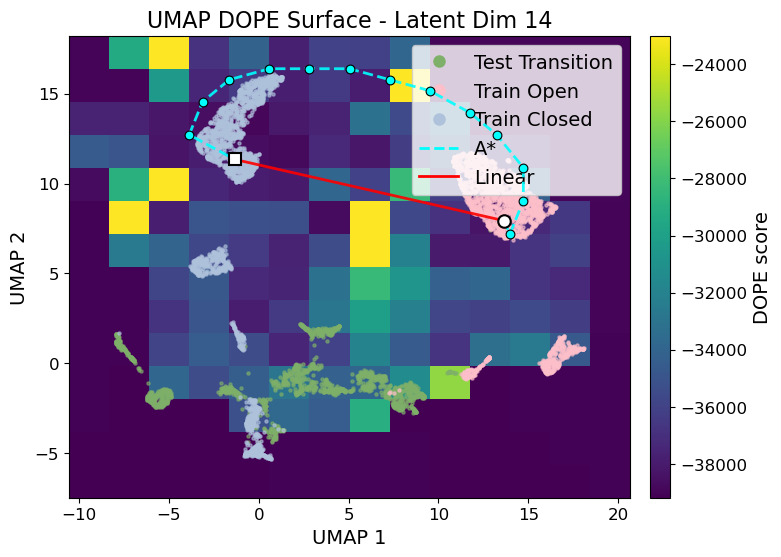

In [ ]:
reducer = umap.UMAP(
    n_components=2, random_state=RANDOM_STATE, n_neighbors=12, min_dist=0.1
)

reducer.fit(encoded_all)

_, _, _, _, _, paths = plot_dope_mesh(
    ma,
    encoded_datasets=encoded_datasets,
    mapping=reducer.transform,
    inverse_mapping=reducer.inverse_transform,
    truncate_at=TRUNCATE_AT,
    n_samples=15,
    refine=REFINE,
    title=f"UMAP DOPE Surface - Latent Dim {var}",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    plot_linear=True,
    plot_astar=True,
    start_encoded=centroid_open,
    end_encoded=centroid_closed,
)

### Evaluation of paths

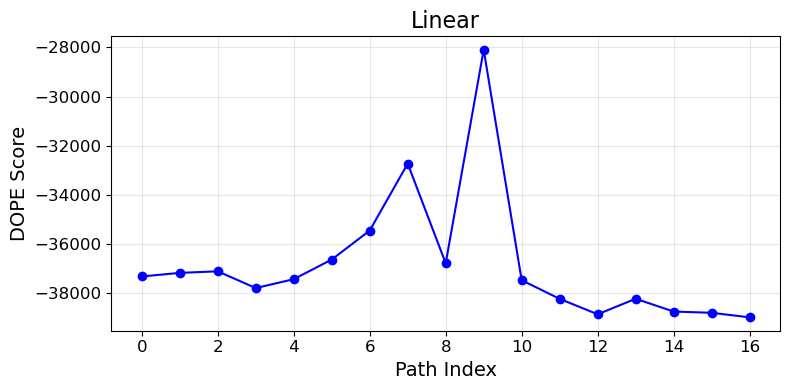

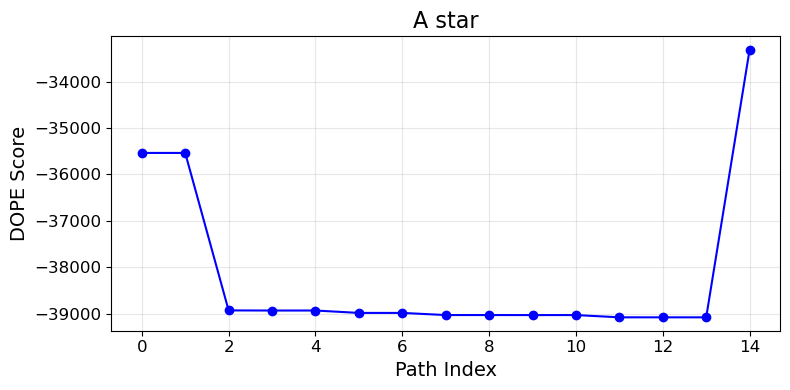

In [8]:
linear = paths["linear"]
a_star = paths["astar"]

plot_dope_interp_scores(linear["dope"], "Linear")
plot_dope_interp_scores(a_star["dope"], "A star")

### OpenMM simulation of interpolations


In [ ]:
protein_decoded = linear["decoded"][0]
print(protein_decoded.shape)

initial_energy, finial_energy, stable = simulate_murd_short_md(
    protein_decoded, "../data/cleaned_aligned_structure.pdb"
)

(2145, 3)


AttributeError: 'NoneType' object has no attribute 'residues'

### Autoencoder offline
Where N = number of conformations and D = latent_dim (dimensionality of models latent space) the autoencoder:

- takes two inputs:
    - dataset in original N x 2145 x 3 cartesian space
    - encoded data in N x 1 x D latent space
- outputs: 
    - hyperlatent representation in N x 1 x 2 space
    - encoded data in N x 1 x D space

The flow of data would be D -> 2 -> D so this autoencoder should work bidirectionally. 

#### Train loop (1 model)

In [ ]:
weights = [
    # [1, 0, 0, 0],
    # [1, 0, 0, 0],
    # [1, 0, 0, 0],
    # [0, 1, 0, 0],
    # [0, 1, 0, 0],
    # [0, 1, 0, 0],
    # [0, 0, 1, 0],
    # [0, 0, 1, 0],
    # [0, 0, 1, 0],
    # [0, 0, 0, 1],
    # [0, 0, 0, 1],
    # [0, 0, 0, 1],
    # [1, 0, 1, 0],  # local and raw rmsd,
    # [0, 1, 0, 1],  # local and raw pairwise distance
    # [1, 0, 0, 1],  # local rmsd, raw pairwise distance
    # [0, 1, 1, 0],  # local pairwise distance and raw RMSD
]

mlp_mas = {}
mappings = {}
inverse_mappings = {}

for i, weight in enumerate(weights):
    mlp_mas[i], mappings[i], inverse_mappings[i] = make_hyperlatent_mlp_mas(
        MAs, [run], [var], KEYS_ALL, weight, epochs=100
    )

    ma = mlp_mas[i][run][var]
    mapping = mappings[i][run][var]
    inverse_mapping = inverse_mappings[i][run][var]

    get_all_stats(
        mas=mlp_mas[i],
        varis=[var],
        runs=[run],
        keys=KEYS_ALL,
        save_dir=f"../statistics/mlp_stats_weight_after_invincibiles_{i}.csv",
        random_state=RANDOM_STATE + i,
    )

    # all_base_plots(
    #     ma=ma,
    #     keys=KEYS_BOTH,
    #     plot_data=plot_data,
    #     latent_dim=var,
    #     run=run,
    #     save_dir=f"../figures/test/mlp/climbing_gym2{i}/",
    # )

    # plot_dope_mesh(
    #     ma=ma,
    #     encoded_datasets=encoded_datasets,
    #     mapping=mapping,
    #     inverse_mapping=inverse_mapping,
    #     truncate_at=TRUNCATE_AT,
    #     n_samples=N_SAMPLES,
    #     refine=REFINE,
    # )

    gc.collect()
    torch.cuda.empty_cache()

encoding train_both: 250it [00:01, 185.62it/s]
Decoding train_open: 125it [00:01, 117.61it/s]
Decoding train_closed: 125it [00:00, 154.54it/s]
Decoding train_both: 250it [00:01, 140.50it/s]
Decoding test_trans: 100it [00:00, 139.62it/s]
encoding train_open: 125it [00:00, 202.49it/s]
encoding train_closed: 125it [00:00, 195.25it/s]
encoding train_both: 250it [00:01, 177.59it/s]
encoding test_trans: 100it [00:00, 169.24it/s]
Decoding train_open: 125it [00:00, 149.13it/s]
Decoding train_closed: 125it [00:00, 138.22it/s]
Decoding train_both: 250it [00:01, 134.78it/s]
Decoding test_trans: 100it [00:00, 139.33it/s]
encoding train_open: 125it [00:00, 199.87it/s]
encoding train_closed: 125it [00:00, 206.07it/s]
encoding train_both: 250it [00:01, 189.81it/s]
encoding test_trans: 100it [00:00, 191.65it/s]
Decoding train_open: 125it [00:00, 153.06it/s]
Decoding train_closed: 125it [00:00, 152.15it/s]
Decoding train_both: 250it [00:01, 143.17it/s]
Decoding test_trans: 100it [00:00, 133.40it/s]


### Hparam tuning

In [ ]:
KEY = ["train_both"]

run = 10
var = 14

ma = MAs[run][var]
weight = [0, 0, 1, 0]
loss_func = composite_loss(ma, weight)
tuned_params = {
    "lr": 0.0005713591816215881,
    "hidden_dim": 128,
    "num_layers": 3,
    "dropout": 0.027172688481867702,
}

model = LatentAutoencoder(
    input_dim=var,
    latent_dim=2,
    hidden_dim=tuned_params["hidden_dim"],
    num_layers=tuned_params["num_layers"],
    dropout=tuned_params["dropout"],
)


train_config = TrainConfig(
    ma=ma,
    model=model,
    keys=KEY,
    epochs=100,
    loss_func=loss_func,
    verbose=True,
    lr=tuned_params["lr"],
    batch_size=64,
    val_split=0.1,
)


mlp_mas, mappings, inverse_mappings, val_losses = make_hyperlatent_mlp_mas(
    MAs, [run], [var], KEYS_ALL, train_config
)

get_all_stats(
    mas=mlp_mas,
    varis=[var],
    runs=[run],
    keys=KEYS_BOTH,
    save_dir="../statistics/mlp_stats_hparam_tuned.csv",
    random_state=RANDOM_STATE,
)


#
# hparam_space = ["lr", "hidden_dim", "num_layers", "dropout"]

encoding train_open: 125it [00:00, 214.44it/s]
encoding train_closed: 125it [00:00, 216.33it/s]
encoding train_both: 250it [00:01, 212.98it/s]
encoding test_trans: 100it [00:00, 220.78it/s]


KeyboardInterrupt: 

In [ ]:
weight = [0, 0, 1, 0]
loss_func = composite_loss(ma, weight)


def objective(trial):
    # Sample hyperparameters
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-3)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 2, 6)
    dropout = trial.suggest_uniform("dropout", 0.0, 0.1)

    # Build model and config
    model = LatentAutoencoder(
        input_dim=var,
        latent_dim=2,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    )

    train_config = TrainConfig(
        ma=ma,
        model=model,
        keys=["train_both"],
        epochs=5,
        loss_func=loss_func,
        verbose=False,
        lr=lr,
        batch_size=64,
    )

    # Train and evaluate
    mlp_mas, mappings, inverse_mappings, val_loss = make_hyperlatent_mlp_mas(
        MAs, [run], [var], KEYS_ALL, train_config
    )
    # Return validation loss or other metric
    loss = val_loss[run][var]  # extract from logs or output

    gc.collect()
    torch.cuda.empty_cache()

    return loss


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-31 13:48:41,364] A new study created in memory with name: no-name-f2fcae0f-53f0-4186-a2f2-377c2a896237
encoding train_open: 125it [00:00, 211.59it/s]
encoding train_closed: 125it [00:00, 245.78it/s]
encoding train_both: 250it [00:01, 240.37it/s]
encoding test_trans: 100it [00:00, 224.65it/s]
[I 2026-03-31 13:49:23,443] Trial 0 finished with value: 0.09178125858306885 and parameters: {'lr': 1.4632651685143156e-05, 'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.02310094542589002}. Best is trial 0 with value: 0.09178125858306885.
encoding train_open: 125it [00:00, 244.39it/s]
encoding train_closed: 125it [00:00, 239.81it/s]
encoding train_both: 250it [00:01, 242.31it/s]
encoding test_trans: 100it [00:00, 247.80it/s]
[I 2026-03-31 13:50:07,913] Trial 1 finished with value: 0.2798624208995274 and parameters: {'lr': 0.0005920104117866173, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.09200099391333527}. Best is trial 0 with value: 0.09178125858306885.
encoding train_open: 125

#### Plotting

Decoding 10x10 = 100 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 100/100 [00:06<00:00, 15.57it/s]


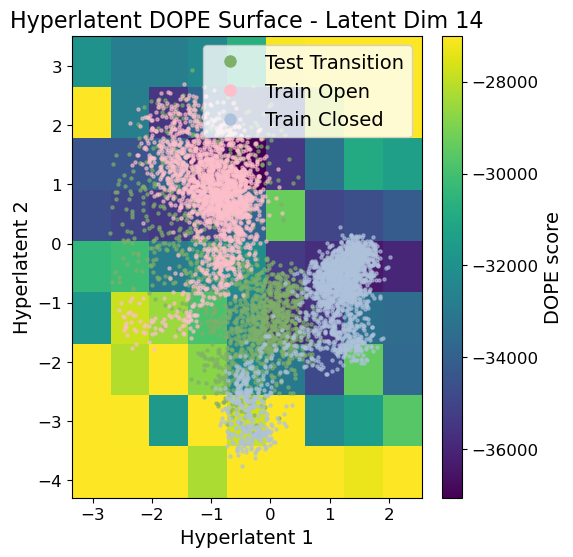

RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x2 and 14x128)

In [ ]:
def ae_encode(x: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model.encode(torch.tensor(x, dtype=torch.float32)).numpy()


def ae_decode(x: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model.decode(torch.tensor(x, dtype=torch.float32)).numpy()


# --- Retrieve DOPE surface and grid from plot_dope_mesh ---
dope_surface, d1_vals, d2_vals, fig, ax = plot_dope_mesh(
    MAs[run][var],
    encoded_datasets=encoded_datasets,
    mapping=ae_encode,
    inverse_mapping=ae_decode,
    n_samples=10,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"Hyperlatent DOPE Surface - Latent Dim {var}",
    xlabel="Hyperlatent 1",
    ylabel="Hyperlatent 2",
)